# 11 - Preparation QA against known targets: breaking the isotropy limit

Notebook 09 proved that without a reference direction, scaling and noise errors are
indistinguishable beyond their norms (isotropy argument, 40% confusion at the Bayes
limit). This notebook changes the setting: the validator now knows WHICH state the
hardware was asked to prepare - a register initialisation, an interferometer input,
a QKD symbol. Direction carries information again.

Error model (see `src/preparation.py`): each sample was supposed to be a known target,
and comes out either `ok` (exact), `rotated` (unitary pointing error - still normalised,
invisible to any norm test) or `scaled` (gain error - direction preserved, invisible to
any fidelity test). All read through shot noise (N = 500).

The candidate statistics:

$$\hat{n} = \big|\,\|\hat{\psi}\|^2 - 1 - 2d\sigma^2\big|, \qquad
\hat{F} = \frac{|\langle \phi_{\mathrm{target}} | \hat{\psi} \rangle|^2}{\|\hat{\psi}\|^2}$$

n-hat sees gain errors only; F-hat is scale-invariant so it sees pointing errors only.
The prediction: each alone caps at 2/3 on three balanced classes, the pair wins.

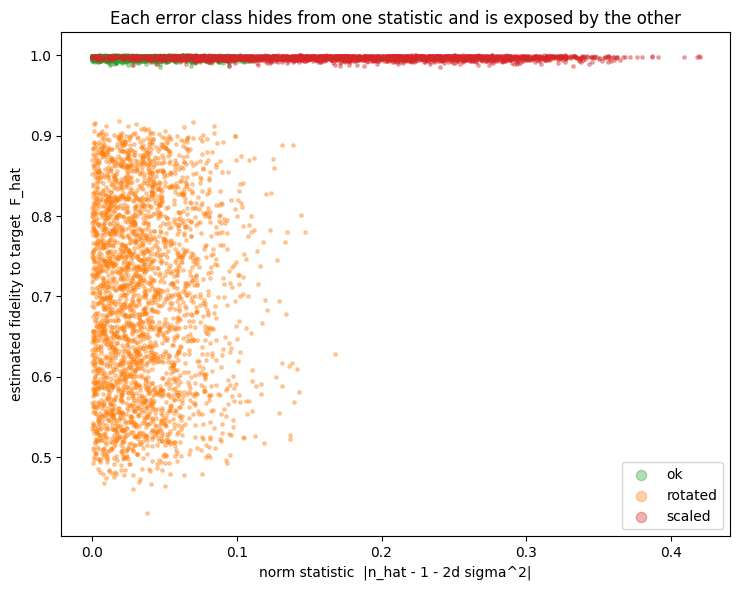

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from src.preparation import create_preparation_dataset, fidelity_to_target
from src.features import extract_amplitudes, sigma_from_shots

RANDOM_STATE, DIM, N_SHOTS = 42, 4, 500

df, targets = create_preparation_dataset(3000, dim=DIM, n_shots=N_SHOTS, seed=RANDOM_STATE)
states = extract_amplitudes(df)
fid = pd.Series(fidelity_to_target(states, targets[df["target_id"]]),
                index=df.index, name="fidelity")
sigma = sigma_from_shots(N_SHOTS)
norm_stat = np.abs(df["norm_squared"] - 1.0 - 2 * DIM * sigma**2).rename("norm_stat")

fig, ax = plt.subplots(figsize=(7.5, 6))
colors = {"ok": "tab:green", "rotated": "tab:orange", "scaled": "tab:red"}
for err, c in colors.items():
    m = df["error_type"] == err
    ax.scatter(norm_stat[m], fid[m], s=6, alpha=0.35, color=c, label=err)
ax.set_xlabel("norm statistic  |n_hat - 1 - 2d sigma^2|")
ax.set_ylabel("estimated fidelity to target  F_hat")
ax.set_title("Each error class hides from one statistic and is exposed by the other")
ax.legend(markerscale=3)
plt.tight_layout(); plt.show()

The plane says it all: `rotated` sits at low fidelity but near-zero norm statistic
(norm-blind), `scaled` sits at high fidelity but large norm statistic (fidelity-blind),
`ok` sits in the corner. Two orthogonal error mechanisms, two orthogonal statistics.

Binary task (accept/reject the preparation):
  norm statistic alone              : 0.6667
  fidelity alone                    : 0.6653
  pair (norm, fidelity)             : 0.9218
  RF on raw amplitudes + target id  : 0.9071



3-class diagnosis, tree on the pair : 0.9253
3-class diagnosis, RF on raw        : 0.9084


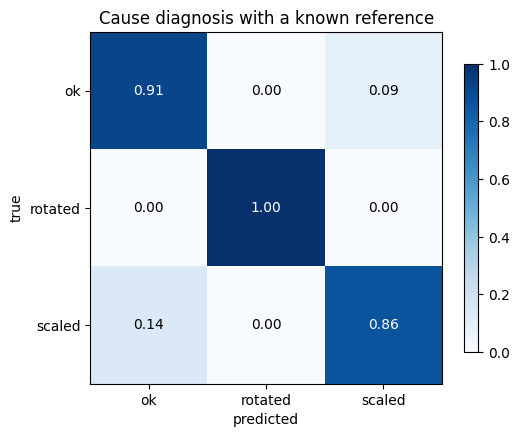

In [2]:
y_bin = df["prep_ok"]
y_cause = df["error_type"]
idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.25,
                                  stratify=y_cause, random_state=RANDOM_STATE)

def fit_acc(model, X, y):
    model.fit(X.iloc[idx_tr], y.iloc[idx_tr])
    return model, accuracy_score(y.iloc[idx_te], model.predict(X.iloc[idx_te]))

pair = pd.concat([norm_stat, fid], axis=1)
raw = df[[c for c in df.columns if c.startswith("c")] + ["target_id"]]

results = {}
_, results["norm statistic alone"] = fit_acc(
    DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE), norm_stat.to_frame(), y_bin)
_, results["fidelity alone"] = fit_acc(
    DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), fid.to_frame(), y_bin)
_, results["pair (norm, fidelity)"] = fit_acc(
    DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), pair, y_bin)
_, results["RF on raw amplitudes + target id"] = fit_acc(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), raw, y_bin)

print("Binary task (accept/reject the preparation):")
for k, v in results.items():
    print(f"  {k:34s}: {v:.4f}")

tree3, acc3 = fit_acc(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE), pair, y_cause)
_, acc3_rf = fit_acc(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), raw, y_cause)
print(f"\n3-class diagnosis, tree on the pair : {acc3:.4f}")
print(f"3-class diagnosis, RF on raw        : {acc3_rf:.4f}")

labels = ["ok", "rotated", "scaled"]
cm = confusion_matrix(y_cause.iloc[idx_te], tree3.predict(pair.iloc[idx_te]),
                      labels=labels, normalize="true")
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Cause diagnosis with a known reference")
plt.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

## Takeaways

1. **Each single statistic caps at ~0.667** - exactly the "blind to one class out of
   three" prediction. Neither is wrong; each answers only half of the question.
2. **The engineered pair reaches 0.92 with a depth-3 tree** and beats the 100-tree
   Random Forest on raw amplitudes (0.91): fourth appearance of the representation
   lesson since notebook 08.
3. **The isotropy limit of notebook 09 is broken**: `rotated` is diagnosed at 100%
   (against 59% recall for `scaling` without a reference). The residual ok/scaled
   confusion (~9-14%) is shot noise pushing band-edge gain errors across the
   threshold - reducible by increasing N, not by a better model.
4. Engineering reading: preparation QA with a known reference is a *two-channel*
   monitor (gain channel + pointing channel), the same architecture as an optical
   bench alignment monitor or an antenna pointing loop. Milestone 4 closes on a
   constructive note: the physics tells you which statistics to build; the model
   confirms their sufficiency.

Remaining for the milestone (see ROADMAP): variable dimensions and the N-vs-error
sizing curves.